In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression 

In [ ]:
train_df = pd.read_csv("train.csv",delimiter=";")
test_df = pd.read_csv("test.csv",delimiter=";")

In [13]:
train_df


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3535,1,51,1,9991,0,39,120.0,1,1,4,...,9,13,13,9,11.333333,0,8.9,1.4,3.51,Dropout
3536,1,39,1,9991,0,1,110.0,1,37,37,...,0,5,0,0,0.000000,0,12.7,3.7,-1.70,Dropout
3537,1,39,2,9147,1,19,133.1,1,38,19,...,0,5,9,0,0.000000,0,10.8,1.4,1.74,Dropout
3538,1,17,5,9254,1,1,118.0,1,19,37,...,0,6,12,4,10.250000,0,7.6,2.6,0.32,Dropout


In [9]:
test_df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,1,9119,1,1,130.0,1,1,3,...,0,0,5,7,0,0.000000,0,9.4,-0.8,-3.12
1,1,17,1,9670,1,1,132.0,1,38,37,...,0,0,6,9,2,13.000000,0,10.8,1.4,1.74
2,1,39,1,9991,0,1,100.0,1,37,38,...,0,0,5,7,4,12.750000,0,15.5,2.8,-4.06
3,1,17,1,9085,1,1,120.0,1,19,38,...,0,0,6,11,5,13.666667,0,11.1,0.6,2.02
4,1,39,1,9991,0,12,133.1,1,37,37,...,0,0,5,9,3,11.333333,1,7.6,2.6,0.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,1,1,6,9773,1,1,125.0,1,1,1,...,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06
880,1,1,2,9773,1,1,120.0,105,1,1,...,0,0,6,6,2,11.000000,0,11.1,0.6,2.02
881,1,1,1,9500,1,1,154.0,1,37,37,...,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79
882,1,1,1,9147,1,1,180.0,1,37,37,...,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12


In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3540 entries, 0 to 3539
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3540 non-null   int64  
 1   Application mode                                3540 non-null   int64  
 2   Application order                               3540 non-null   int64  
 3   Course                                          3540 non-null   int64  
 4   Daytime/evening attendance	                     3540 non-null   int64  
 5   Previous qualification                          3540 non-null   int64  
 6   Previous qualification (grade)                  3540 non-null   float64
 7   Nacionality                                     3540 non-null   int64  
 8   Mother's qualification                          3540 non-null   int64  
 9   Father's qualification                   

In [18]:
train_df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,...,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000,3540.000000
mean,1.173729,18.673729,1.732486,8858.282768,0.889831,4.483898,132.445621,1.853107,19.180226,21.976836,...,0.140678,0.531921,6.216384,7.998023,4.444068,10.218415,0.151977,11.607006,1.210028,0.006850
std,0.589576,17.488737,1.317140,2060.697591,0.313145,10.101101,13.232719,6.802913,15.567580,15.402595,...,0.698350,1.888933,2.172567,3.908569,3.009541,5.213759,0.760764,2.663956,1.379466,2.268117
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,124.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.000000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.343125,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,43.000000,43.000000,...,12.000000,19.000000,23.000000,28.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


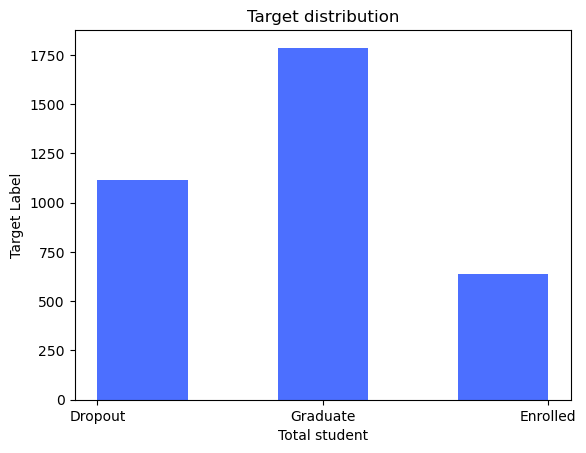

In [20]:
plt.hist(train_df["Target"],bins=5, color="#4C6FFF")
plt.title("Target distribution")
plt.xlabel("Total student")
plt.ylabel("Target Label")
plt.show()

In [22]:
X = train_df.drop(columns=["Target"])
Y = train_df["Target"]

In [23]:
model = LogisticRegression()

In [24]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
model.fit(X, Y)

c:\Users\chris\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
X_test = test_df

In [29]:
Predictions=model.predict(X_test)

In [30]:
Predictions

array(['Dropout', 'Graduate', 'Dropout', 'Graduate', 'Dropout',
       'Graduate', 'Graduate', 'Dropout', 'Dropout', 'Graduate',
       'Enrolled', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Dropout', 'Graduate', 'Graduate',
       'Dropout', 'Graduate', 'Dropout', 'Graduate', 'Dropout', 'Dropout',
       'Graduate', 'Graduate', 'Graduate', 'Dropout', 'Enrolled',
       'Graduate', 'Dropout', 'Dropout', 'Graduate', 'Graduate',
       'Dropout', 'Dropout', 'Dropout', 'Graduate', 'Graduate',
       'Enrolled', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Graduate', 'Graduate', 'Dropout', 'Dropout',
       'Graduate', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Graduate', 'Graduate', 'Dropout',
       'Graduate', 'Graduate', 'Enrolled', 'Graduate', 'Graduate',
       'Graduate', 'Dropout', 'Graduate', 'Dropout', 'Graduate',
       'Graduate', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       